# Analysis of English Corpus

The following analysis performs an exploratory data analysis on an English language corpus. The analysis will focus on identifying patterns that will be relevant to the development of the solvers.

### Explanation of the data

https://pypi.org/project/wordfreq/

The `wordfreq` Python module provides word frequency data for English and over 40 other languages. The English word frequency data in wordfreq is compiled from multiple sources to avoids bias toward any single domain or style of text:

1. Wikipedia - encyclopedic text
1. Subtitles - OPUS OpenSubtitles 2018 and SUBTLEX
1. News - NewsCrawl 2014 and GlobalVoices
1. Books - Google Books Ngrams 2012
1. Web text - OSCAR
1. Twitter - social media language
1. Reddit - online discussion forums


### Loading the data

In [1]:
from wordfreq import iter_wordlist
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
words = [word.upper() for word in iter_wordlist('en', wordlist='large') if len(word) == 5 and word.isalpha() and word.isascii()]

print(f"Found {len(words)} five-letter English words")

words = sorted(words)

Found 38208 five-letter English words


In [3]:
words = pd.DataFrame(words, columns=['word'])
print(words.head(), '\n', words.shape)

    word
0  AAAAA
1  AAAAH
2  AAAGH
3  AAAHH
4  AAAND 
 (38208, 1)


In [4]:
letters = ['letter_1', 'letter_2', 'letter_3', 'letter_4', 'letter_5']
for i in range(5):
    words[letters[i]] = words['word'].str[i]

words.head()

,word,letter_1,letter_2,letter_3,letter_4,letter_5
0,AAAAA,A,A,A,A,A
1,AAAAH,A,A,A,A,H
2,AAAGH,A,A,A,G,H
3,AAAHH,A,A,A,H,H
4,AAAND,A,A,A,N,D


### What are the most common letters?

In [5]:
letter_counts = words[['letter_1', 'letter_2', 'letter_3', 'letter_4', 'letter_5']].apply(pd.Series.value_counts)
letter_counts['sum'] = letter_counts.sum(axis=1)
letter_counts

,letter_1,letter_2,letter_3,letter_4,letter_5,sum
A,2732,8438,3188,4327,5086,23771
B,2588,324,1091,831,213,5047
C,2151,461,1206,1308,448,5574
D,1903,337,1433,1503,1090,6266
E,1119,4929,2400,5031,4234,17713
F,1350,181,445,419,247,2642
G,1581,215,1108,1035,582,4521
H,1631,1621,736,1019,1123,6130
I,881,4095,2688,3416,2626,13706
J,902,82,276,254,41,1555


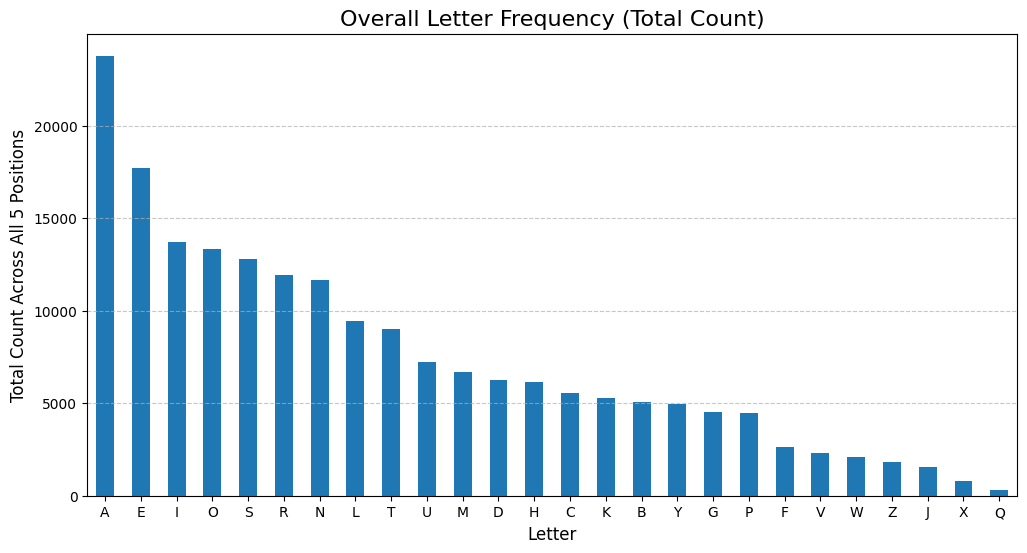

In [6]:
plot_data = letter_counts['sum'].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plot_data.plot(kind='bar')
plt.title('Overall Letter Frequency (Total Count)', fontsize=16)
plt.xlabel('Letter', fontsize=12)
plt.ylabel('Total Count Across All 5 Positions', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

### What are the most common letters in each position?

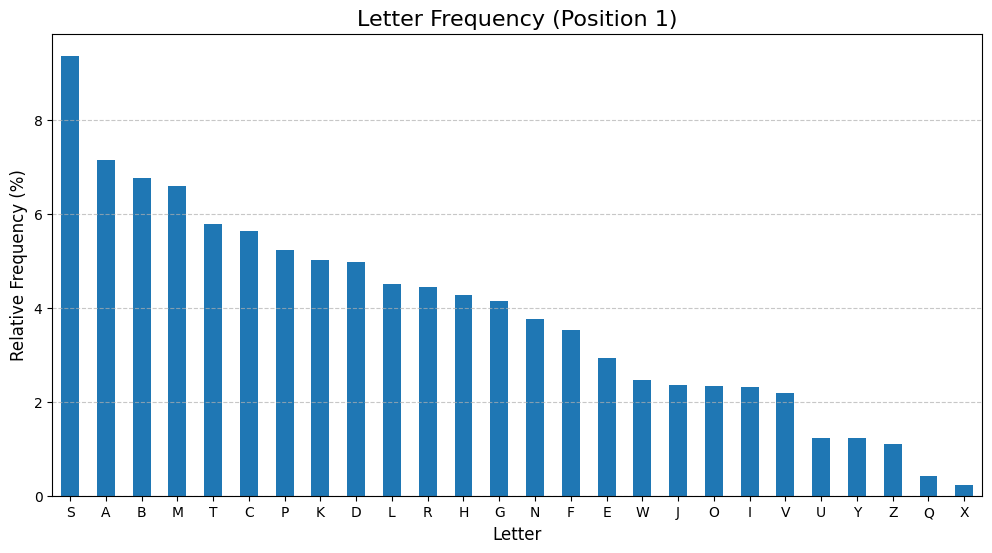

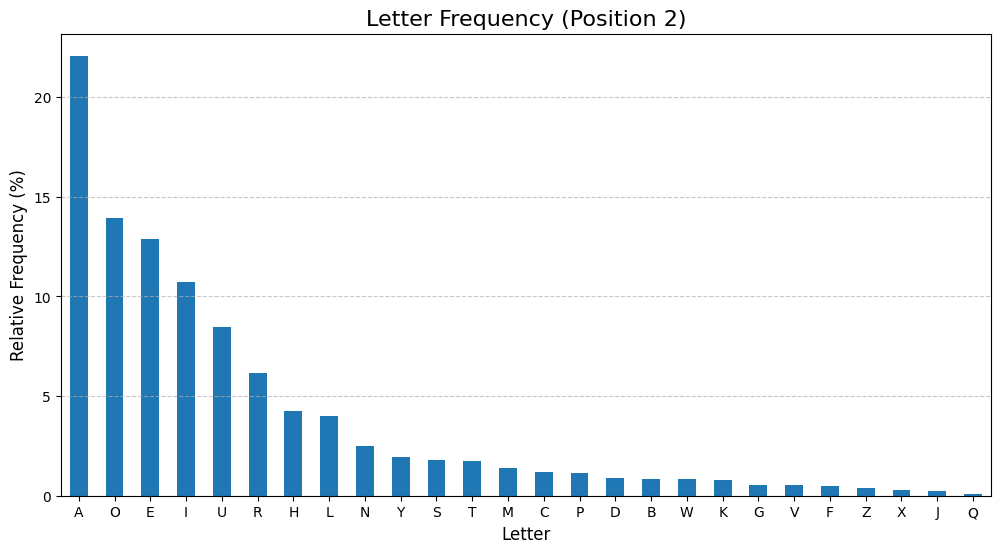

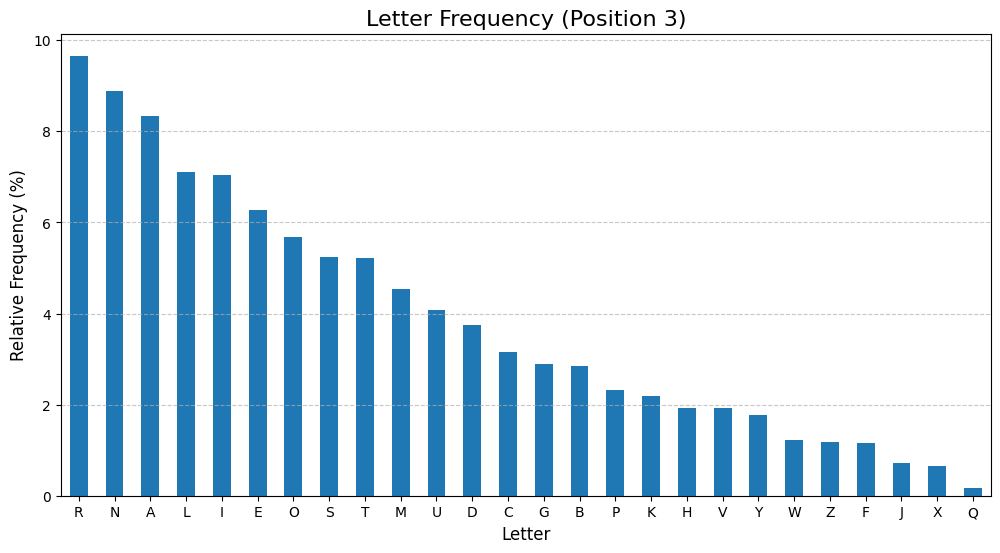

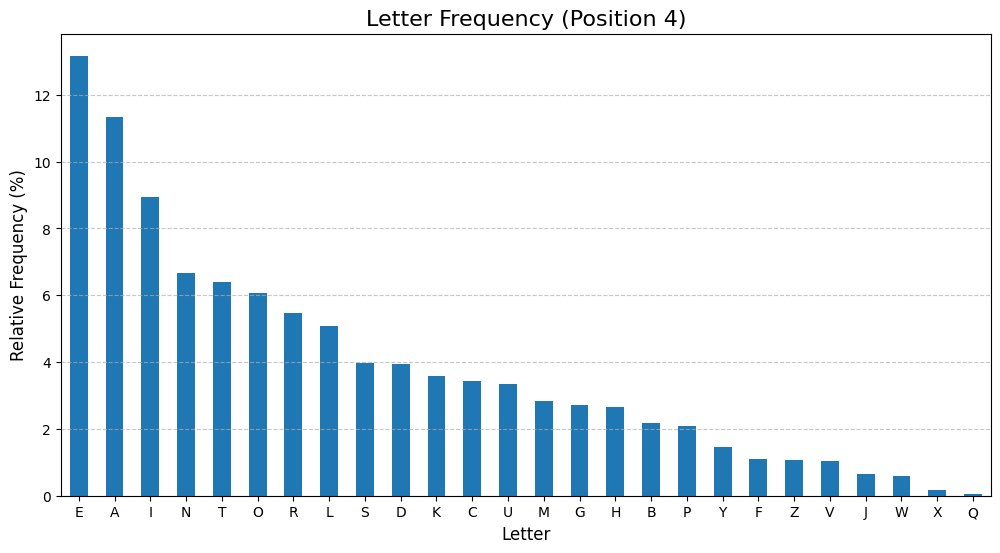

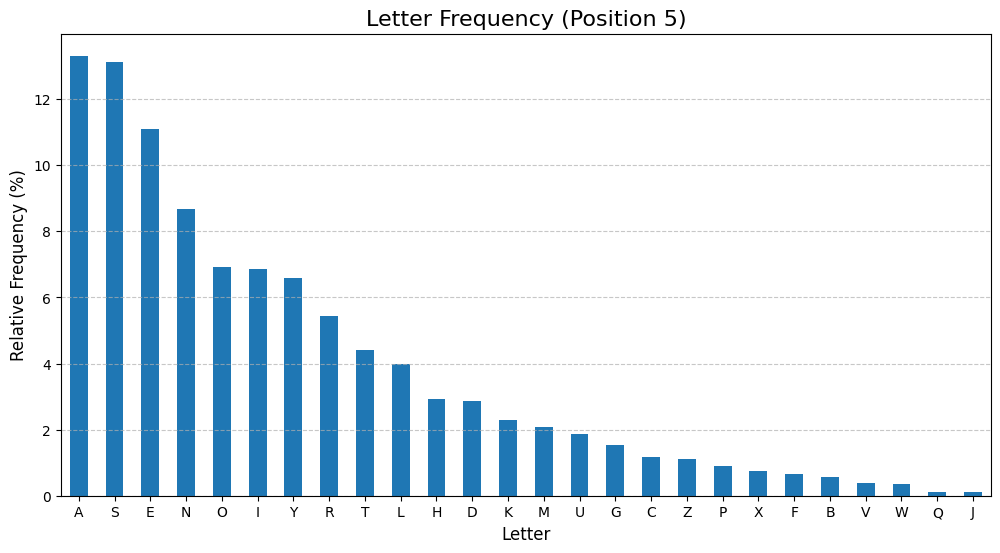

In [7]:
for i in range(5):

    total = letter_counts[f'letter_{i+1}'].sum()

    plot_data = (letter_counts[f'letter_{i+1}'] / total * 100)
    
    all_letters = list('ABCDEFGHIJKLMNOPQRSTUVWXYZ')
    plot_data = plot_data.reindex(all_letters, fill_value=0).sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    plot_data.plot(kind='bar')
    plt.title(f'Letter Frequency (Position {i+1})', fontsize=16)
    plt.xlabel('Letter', fontsize=12)
    plt.ylabel('Relative Frequency (%)', fontsize=12)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

### How are vowels distributed?

In [8]:
vowels = set('AEIOU')

words['vowel_count'] = words['word'].apply(lambda x: sum(1 for letter in x if letter in vowels))
print(f'The average number of vowels in each word is {words["vowel_count"].mean():.2f}')

The average number of vowels in each word is 1.98


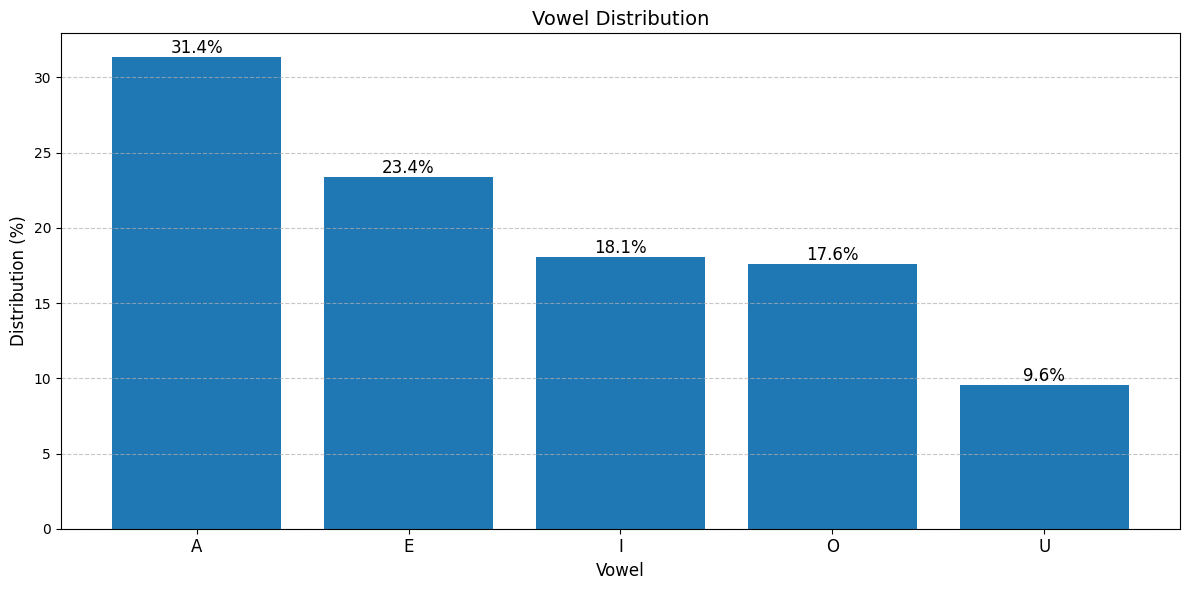

In [9]:
vowels = ['A', 'E', 'I', 'O', 'U']

counts = {v: words['word'].str.count(v).sum() for v in vowels}
total = sum(counts.values())
vowel_dist = pd.Series([(counts[v] / total) * 100 for v in vowels], index=vowels)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(vowels))

bars = ax.bar(x, vowel_dist)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%',
            ha='center', va='bottom', fontsize=12)

ax.set_xlabel('Vowel', fontsize=12)
ax.set_ylabel('Distribution (%)', fontsize=12)
ax.set_title('Vowel Distribution', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(vowels, fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### How many words have duplicate letters?

In [10]:
words_dupe_count = words['word'].apply(lambda x: len(set(x)) < 5).sum()
print(f'Number of words with duplicate letters is {words_dupe_count} out of {len(words)} ({words_dupe_count/len(words)*100:.2f}%)')

Number of words with duplicate letters is 15699 out of 38208 (41.09%)
